In [ ]:
from src.config import DATA_DIR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Set publication-quality defaults
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

counts_df = pd.read_csv(f'{DATA_DIR}/metadata/atom_type_counts.csv')

types_list_1d = (
    counts_df.loc[
        (counts_df['local_reference_frame'] == 'Isotropic') &
        (counts_df['total_occurrence'] > 1000),
        'atom_type'
    ]
    .dropna()
    .unique()
    .tolist()
)

types_list_2d = (
    counts_df.loc[
        (counts_df['local_reference_frame'] == 'Axial') &
        (counts_df['total_occurrence'] > 1000),
        'atom_type'
    ]
    .dropna()
    .unique()
    .tolist()
)

types_list_3d = (
    counts_df.loc[
        (counts_df['local_reference_frame'] == 'Anisotropic') &
        (counts_df['total_occurrence'] > 1000),
        'atom_type'
    ]
    .dropna()
    .unique()
    .tolist()
)

ligand_types_list = (
    counts_df.loc[
        (counts_df['total_occurrence'] > 500),
        'atom_type'
    ]
    .dropna()
    .unique()
    .tolist()
)

prot_types_list = types_list_1d + types_list_2d + types_list_3d

r_bins = np.arange(1.0, 6.0, 0.1)
theta_bins = np.arange(0, 90.0, 3.0)
phi_bins = np.arange(0, 180, 3.0)

loaded = np.load(f'{DATA_DIR}/potentials/despot_scores.npz')
#scores_1d = loaded['scores_1d']
#scores_2d = loaded['scores_2d']
scores_3d = loaded['scores_3d']

loaded = np.load(f'{DATA_DIR}/potentials/despot_iso_scores.npz')
scores_isotropic = loaded['scores_1d']


C:\Users\robin\AppData\Local\Temp\ipykernel_33648\1695405182.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


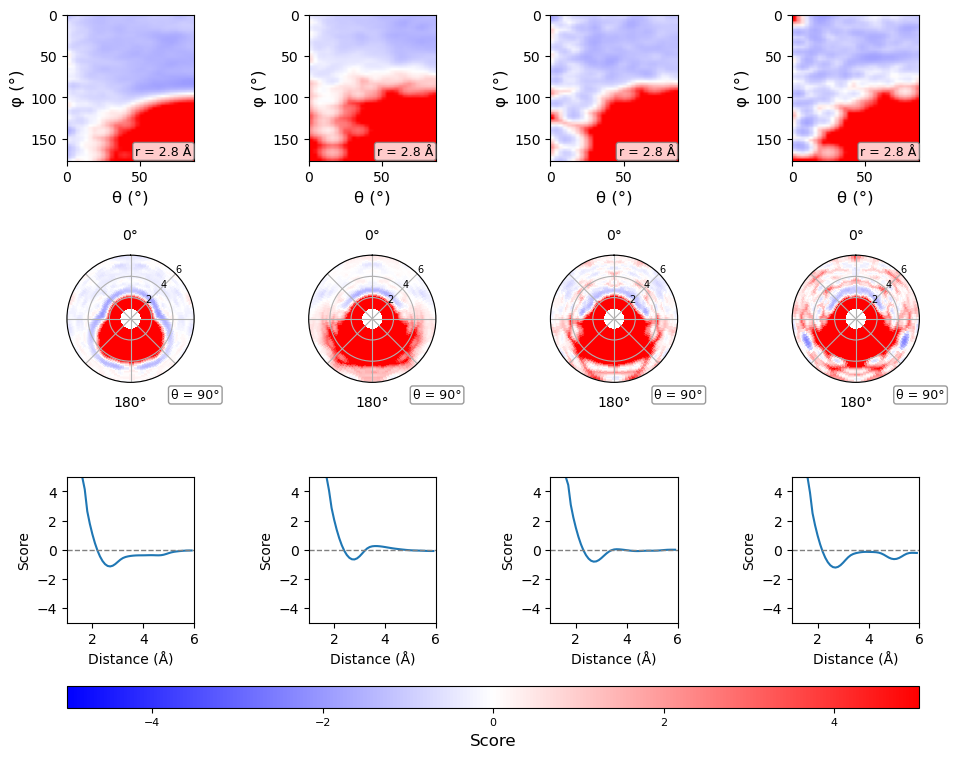

In [ ]:
def plot_anisotropy_v1(p_type_list, l_idx):
    """Multiple p-types, one l-type"""

    L = len(p_type_list)
    fig = plt.figure(figsize = (11, 9))

    gs = GridSpec(4, L, figure=fig, 
                  height_ratios=[1, 1.3, 1, 0.15],
                  wspace=0.9, hspace=0.5)
    
    axes_top = [fig.add_subplot(gs[0,i]) for i in range(L)]
    axes_mid = [fig.add_subplot(gs[1,i], projection = 'polar') for i in range(L)]
    axes_bottom = [fig.add_subplot(gs[2,i]) for i in range(L)]

    phi_bins_rad = np.deg2rad(phi_bins)
    phi_full = np.concatenate([phi_bins_rad, 2*np.pi - phi_bins_rad[-2::-1]])
    R, PHI = np.meshgrid(r_bins, phi_full, indexing = 'ij')

    for i, p_type in enumerate(p_type_list):

        p_idx_3d = types_list_3d.index(p_type)
        subset = scores_3d[p_idx_3d, l_idx, 18, :, :] # [theta, phi]

        x_vals = theta_bins
        y_vals = phi_bins
        extent = [x_vals[0], x_vals[-1], y_vals[-1], y_vals[0]]

        im = axes_top[i].imshow(subset.T, aspect = 'auto', origin = 'upper',
            extent = extent, cmap = 'bwr', vmin = -5, vmax = 5)
    
        axes_top[i].set_xlabel('θ (°)', fontsize = 12)
        axes_top[i].set_ylabel('φ (°)', fontsize = 12)
        # Add text indicating fixed distance
        axes_top[i].text(0.98, 0.02, 'r = 2.8 Å', transform=axes_top[i].transAxes, 
             fontsize=9, ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      edgecolor='gray', alpha=0.8))

        axes_mid[i].set_theta_zero_location('N')
        axes_mid[i].set_theta_direction(-1)

        score_data = scores_3d[p_idx_3d, l_idx, :, -1, :]
        score_full = np.concatenate([score_data, score_data[:, -2::-1]], axis = 1)

        c = axes_mid[i].pcolormesh(PHI, R, score_full, shading = 'auto', cmap = 'bwr', vmin = -5, vmax = 5)

        axes_mid[i].set_ylim(0, 6)
        axes_mid[i].set_yticks([2, 4, 6])
        axes_mid[i].set_yticklabels(['2', '4', '6'], fontsize=7)
        axes_mid[i].set_rlabel_position(45)
        axes_mid[i].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4])
        axes_mid[i].set_xticklabels(['0°', '', '', '', '180°', '', '', ''])
        axes_mid[i].text(1.20, -0.15, 'θ = 90°', transform=axes_mid[i].transAxes, 
             fontsize=9, ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      edgecolor='gray', alpha=0.8))

        # Bottom plot: show isotropic plots
        p_idx_iso = prot_types_list.index(p_type)
        score_data = scores_isotropic[p_idx_iso, l_idx, :]
        axes_bottom[i].plot(r_bins, score_data)
        axes_bottom[i].set_xlim(1, 6)
        axes_bottom[i].set_ylim(-5, 5)
        axes_bottom[i].set_xlabel('Distance (Å)', fontsize = 10)
        axes_bottom[i].set_ylabel('Score', fontsize = 10)
        axes_bottom[i].axhline(0, color = 'gray', linestyle = '--', linewidth = 1)

    # ---- Colorbar ----
    cbar_ax = fig.add_subplot(gs[3, :])
    cbar = fig.colorbar(c, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Score', fontsize=12)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    fig.savefig('sp2O.png', dpi = 600)
    plt.show()

l_idx = ligand_types_list.index('N.4_1')
p_type_list = ['O.co2_1', 'O.am_1', 'O.ke_1', 'O.al_1']
plot_anisotropy_v1(p_type_list, l_idx)

C:\Users\robin\AppData\Local\Temp\ipykernel_23136\4223911634.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


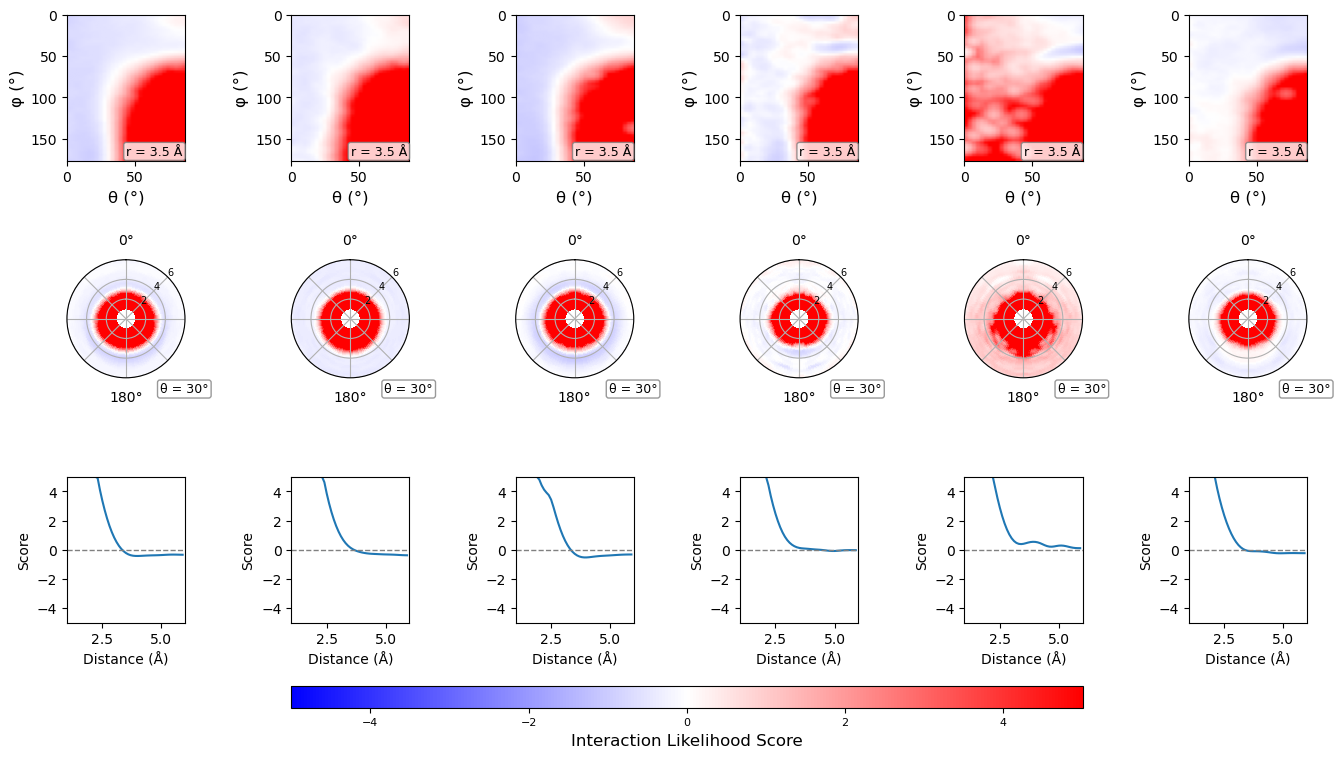

In [ ]:
def plot_anisotropy_v2(p_type, l_type_list):
    """Multiple l-types, one p-type"""

    L = len(l_type_list)
    fig = plt.figure(figsize = (16, 9))

    gs = GridSpec(4, L, figure=fig, 
                  height_ratios=[1, 1.3, 1, 0.15],
                  wspace=0.9, hspace=0.5)
    
    axes_top = [fig.add_subplot(gs[0,i]) for i in range(L)]
    axes_mid = [fig.add_subplot(gs[1,i], projection = 'polar') for i in range(L)]
    axes_bottom = [fig.add_subplot(gs[2,i]) for i in range(L)]

    phi_bins_rad = np.deg2rad(phi_bins)
    phi_full = np.concatenate([phi_bins_rad, 2*np.pi - phi_bins_rad[-2::-1]])
    R, PHI = np.meshgrid(r_bins, phi_full, indexing = 'ij')

    for i, l_type in enumerate(l_type_list):

        l_idx = ligand_types_list.index(l_type)
        p_idx_3d = types_list_3d.index(p_type)
        subset = scores_3d[p_idx_3d, l_idx, 25, :, :] # [theta, phi]

        x_vals = theta_bins
        y_vals = phi_bins
        extent = [x_vals[0], x_vals[-1], y_vals[-1], y_vals[0]]

        im = axes_top[i].imshow(subset.T, aspect = 'auto', origin = 'upper',
            extent = extent, cmap = 'bwr', vmin = -5, vmax = 5)
    
        axes_top[i].set_xlabel('θ (°)', fontsize = 12)
        axes_top[i].set_ylabel('φ (°)', fontsize = 12)
        # Add text indicating fixed distance
        axes_top[i].text(0.98, 0.02, 'r = 3.5 Å', transform=axes_top[i].transAxes, 
             fontsize=9, ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      edgecolor='gray', alpha=0.8))

        axes_mid[i].set_theta_zero_location('N')
        axes_mid[i].set_theta_direction(-1)

        score_data = scores_3d[p_idx_3d, l_idx, :, 10, :]
        score_full = np.concatenate([score_data, score_data[:, -2::-1]], axis = 1)

        c = axes_mid[i].pcolormesh(PHI, R, score_full, shading = 'auto', cmap = 'bwr', vmin = -5, vmax = 5)

        axes_mid[i].set_ylim(0, 6)
        axes_mid[i].set_yticks([2, 4, 6])
        axes_mid[i].set_yticklabels(['2', '4', '6'], fontsize=7)
        axes_mid[i].set_rlabel_position(45)
        axes_mid[i].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4])
        axes_mid[i].set_xticklabels(['0°', '', '', '', '180°', '', '', ''])
        axes_mid[i].text(1.20, -0.15, 'θ = 30°', transform=axes_mid[i].transAxes, 
             fontsize=9, ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      edgecolor='gray', alpha=0.8))

        # Bottom plot: show isotropic plots
        p_idx_iso = prot_types_list.index(p_type)
        score_data = scores_isotropic[p_idx_iso, l_idx, :]
        axes_bottom[i].plot(r_bins, score_data)
        axes_bottom[i].set_xlim(1, 6)
        axes_bottom[i].set_ylim(-5, 5)
        axes_bottom[i].set_xlabel('Distance (Å)', fontsize = 10)
        axes_bottom[i].set_ylabel('Score', fontsize = 10)
        axes_bottom[i].axhline(0, color = 'gray', linestyle = '--', linewidth = 1)

    # ---- Colorbar ----
    cbar_ax = fig.add_subplot(gs[3, 1:-1])
    cbar = fig.colorbar(c, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Interaction Likelihood Score', fontsize=12)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    fig.savefig('pi_stacking.png', dpi = 600)
    plt.show()

p_type = 'C.ar6_2'
l_type_list = ['C.ar6_2', 'C.am_3', 'C.3c_1', 'N.4_1', 'O.2p_1', 'O.3oh_1']
plot_anisotropy_v2(p_type, l_type_list)